## LinearRegression 클래스 - Ordinary Least Squares
* 에측값과 실제값의 RSS를 최소화해 OLS(Ordinary Least Squares) 추정방식으로 구현한 클래스
* fit() 메서드로 X, y 배열을 입력받으면 회귀계수 W를 coef_ 속성에 저장함
* 클래스 입력 파라미터
  * fit_intercept : 불린 값. 디폴트는 True. intercept(절편)을 계산할지 말지 지정. False이면 intercept 지정 않고 0이 됨
  * normalize : 불린 값. 디폴트는 False. False 일 때 파라미터가 무시됨. True이면 회귀 수행 전에 입력 데이터셋을 정규화함
* 클래스 속성
  * coef_ : fit() 메서드를 수행시 회귀 계수가 배열 형태로 저장하는 속성. shape는 (타겟 값 개수, 피처 개수) 임
  * intercept_ : 절편값
* 다중 공선성(multi-collinearity) 문제
  * OLS 기반 회귀 계수 계산은 입력 피처의 독립성에 많은 영향을 받음
  * 피처 간의 상관관계가 매우 높으면 분산이 매우 큼 -> 오류에 민감해지는 문제
  * 상관관계가 높은 피처가 많은 경우 독립적 중요 피처만 남기고 제거하거나 규제 적용
  * 매우 많은 피처가 다중 공선성 문제 있다면 PCA 통해 차원 축소도 가능

## 회귀 평가 지표
* 실제 값과 회귀 예측값의 차이 값을 기반으로 한 지표가 중심
* 평가 지표 예
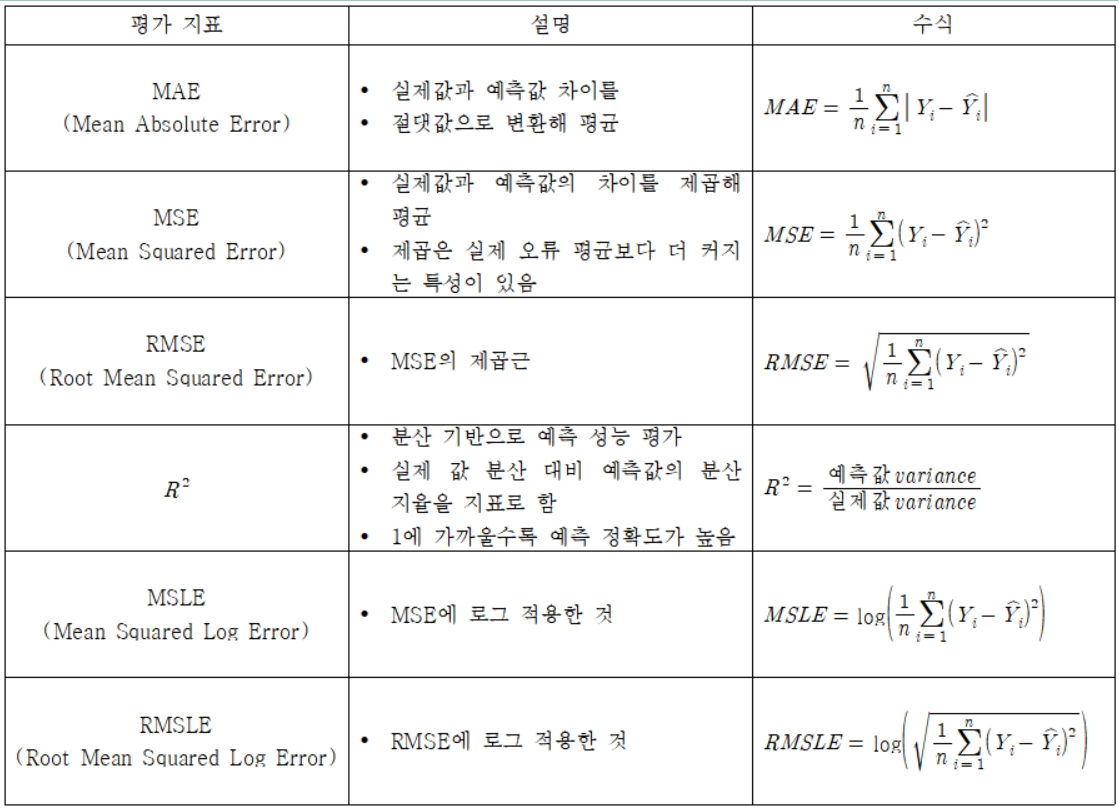
* 사이킷런은 RMSE 제공 안함
* 각 평가 방법에 대한 사이킷런의 API 및 cross_val_score나 GridSearchCV에서 평가시 사용되는 scoring 파라미터 적용값
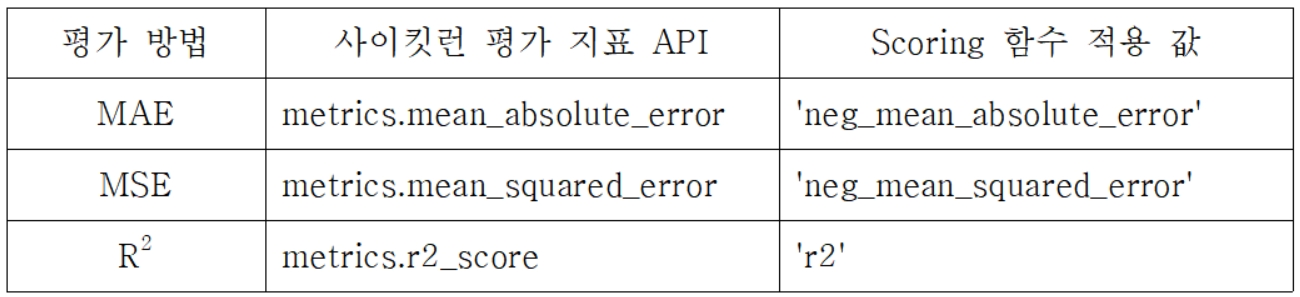
* 접두어 neg는 음수 Negative
  * MAE는 절댓값의 합이므로 음수가 될 수 없음
  * Scoring ㅎ마수에 neg_mean_absolute_error 적용해 음수값 반환하는 이유
    * 사이킷런 scoring 함수가 socre이 클수록 좋은 평과 결과로써 자동 평가하므로(특히 GridSearchCV는 가장 좋은 evaluation 값 가지는 하이퍼 파라미터로 학습까지 자동으로 시킴)
    * 실제 값과 예측값의 초라를 기반으로 하는 회귀 평가 지표 값 커지면 오히려 나쁜 모델이라는 의미임 -> 시이킷런의 scoring 함수에 일반적으로 반영하려면 보정 필요
    * -1을 원래 평가 지표에 곱해서 음수를 만들면 -> 작은 오류 값이 더 큰 숫자로 인식하게 됨
  * metrics.mean_absolute_error() 등의 평가 지표 API는 정상적으로 양수 값 반환 <-> scoring 함수의 scoring 파라미터값 neg_mean_absoulute_error가 의미하는 것은 -1*metrics.mean_absolute_error() 임에 주의

## LinearRegression 을 이용해 보스턴 주택 가격 회귀 구현
* 주요 피처
  * CRIM : 지역별 범죄 발생률
  * ZN : 25000 평방피트 초과하는 거주 지역의 비율
  * INDUS : 비상업 지역 넓이 비율
  * CHAS : 찰스강에 대한 더미 변수. 강 경계 위치할 때 1, 아니면 0
  * NOX : 일산화질소 농도
  * RM : 거주할 수 있는 방의 개수
  * AGE : 1940년 이전에 건축된 소유 주택으 ㅣ비율
  * DIS : 5개 주요 고용센터까지의 가중 거리
  * RAD : 고속도로 접근 용이도
  * TAX : 10000달러당 재산세율
  * PTRATIO : 지역의 교사와 학생수 비율
  * B : 지역의 흑인 거주 비율
  * LSTAT : 하위 계층의 비율
  * MEDV : 본인 소유의 주택 가격(중앙값)

In [1]:
# 데이터 로드 및 DataFrame으로 변경
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
%matplotlib inline

boston = load_boston()
boston_df = pd.DataFrame(boston.data, columns=boston.feature_names)
boston_df['PRICE'] = boston.target
print('Boston 데이터세트 크기 : ', boston_df.shape)
boston_df.head()

Boston 데이터세트 크기 :  (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


* NULL 값 없음
* 8개의 피처에 대해 알아보자

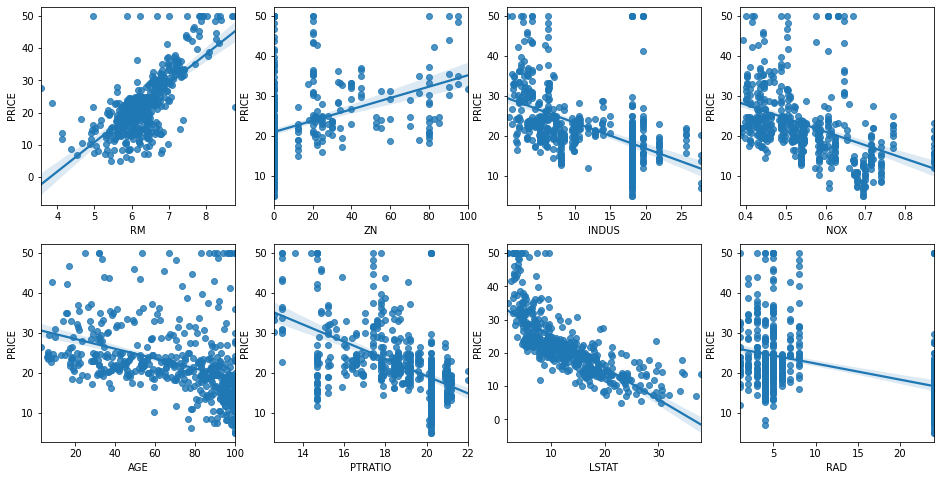

In [3]:
# Seaborn의 regplot() API로 X, Y축 값의 산점도와 함께 선형 회귀 직선 그리기
# Matplotlib의 subplots()으로 여러 개의 그래프 한 번에 그리기

fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    sns.regplot(x=feature, y="PRICE", data=boston_df, ax=axs[row][col])

* RM(방 개수), LSTAT의 PRICE 영향도가 가장 두드러짐
* RM은 양(positive)방향의 선형성이 가장 큼
* LSTAT는 음(negative)방향의 선형성이 가장 큼

In [8]:
# 주택 가격의 회귀 모델 만들기

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = boston_df['PRICE']
x_data = boston_df.drop(['PRICE'], axis=1, inplace=False)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, test_size=0.3, random_state=156)

lr = LinearRegression()
lr.fit(x_train, y_train)
y_preds = lr.predict(x_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print("MSE : {0:.3f} , RMSE : {1:.3f}".format(mse, rmse))
print("Variance score : {0:.3f}".format(r2_score(y_test, y_preds)))

MSE : 17.297 , RMSE : 4.159
Variance score : 0.757


In [9]:
print("절편 값 : ", lr.intercept_)
print("회귀 계수 값 : ", np.round(lr.coef_, 1))

절편 값 :  40.995595172164336
회귀 계수 값 :  [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [10]:
# coef_속성은 회귀 계수값만 가지고 있ㅇ므로 이를 피처별 회귀 계수로 다시 매핑 & 높은 값 순으로 출력

coeff = pd.Series(data=np.round(lr.coef_, 1), index=x_data.columns) #정렬 위해 Series로 생성
coeff.sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
B           0.0
TAX        -0.0
AGE         0.0
INDUS       0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

* 회귀 계수로는 RM이 가장 크고 NOX는 -값이 너무 커보임 -> 최적화 수행하며 피처 coefficients 변화도 봐야 함

In [11]:
# 5개의 폴드 세트에서 교차 검증으로 MSE와 RMSE 측정

from sklearn.model_selection import cross_val_score

y_target = boston_df['PRICE']
x_data = boston_df.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, x_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5folds의 개별 Negative MSE scores : ', np.round(neg_mse_scores, 2))
print('5folds의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print('5folds의 평균 RMSE scores : ', np.round(avg_rmse))

5folds의 개별 Negative MSE scores :  [-12.46 -26.05 -33.07 -80.76 -33.31]
5folds의 개별 RMSE scores :  [3.53 5.1  5.75 8.99 5.77]
5folds의 평균 RMSE scores :  6.0
